Image/Face Track
### Formative 2: Multimodal Data Preprocessing — Facial Recognition Pipeline

This notebook covers my individual contribution to the group's multimodal (image + audio + product recommendation) system:

1. Collect & load my own 3 face images (neutral, smile, surprised) + all teammates' images
2. Apply augmentations (rotation, flip, grayscale) to all image data
3. Extract features (HOG + color histograms) → `image_features.csv`
4. Build, train, and evaluate a **Facial Recognition Model** (Accuracy, F1, Loss)
5. Simulate one "unauthorized" face attempt for the system demo

Built for Google Colab. Run cells top to bottom.

In [2]:
# --- Setup ---
!pip install scikit-image -q

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, log_loss
from sklearn.preprocessing import LabelEncoder

np.random.seed(42)

## 1. Collect face images

Each group member needs **3 images**: `neutral`, `smile`, `surprised`.

Update `MEMBERS` below with the actual teammates' names. Folder structure created:
`/content/faces/<member_name>/<expression>.jpg`

Run the upload cell once per member


In [ ]:
from google.colab import files

MEMBERS = ["Sheilla", "Kevin", "James"]
EXPRESSIONS = ["neutral", "smile", "surprised"]

BASE_DIR = "/content/faces"
os.makedirs(BASE_DIR, exist_ok=True)
for member in MEMBERS:
    os.makedirs(os.path.join(BASE_DIR, member), exist_ok=True)

print("Folder structure ready:")
for member in MEMBERS:
    print(f"  {BASE_DIR}/{member}/")
print("\nSave each image as neutral.jpg / smile.jpg / surprised.jpg inside the right folder.")

Folder structure ready:
  /content/faces/Sheilla/
  /content/faces/Kevin/
  /content/faces/James/

Save each image as neutral.jpg / smile.jpg / surprised.jpg inside the right folder.


In [ ]:
print("Upload your 3 images (neutral.jpg, smile.jpg, surprised.jpg)")
uploaded = files.upload()

my_folder = os.path.join(BASE_DIR, "James")
for fname, content in uploaded.items():
    dest = os.path.join(my_folder, fname)
    with open(dest, "wb") as f:
        f.write(content)
print("Saved to", my_folder)

Upload your 3 images (neutral.jpg, smile.jpg, surprised.jpg)


Saving james_neutral.jpg to james_neutral.jpg
Saving james_smile.jpg to james_smile.jpg
Saving james_suprised.jpg to james_suprised.jpg
Saved to /content/faces/James


In [ ]:
teammate_name = "Kevin"
print(f"Upload {teammate_name}'s 3 images (neutral.jpg, smile.jpg, surprised.jpg)")
uploaded = files.upload()

folder = os.path.join(BASE_DIR, teammate_name)
os.makedirs(folder, exist_ok=True)
for fname, content in uploaded.items():
    dest = os.path.join(folder, fname)
    with open(dest, "wb") as f:
        f.write(content)
print("Saved to", folder)

Upload Kevin's 3 images (neutral.jpg, smile.jpg, surprised.jpg)


Saving kevin_neutral.jpg to kevin_neutral.jpg
Saving kevin_smile.jpg to kevin_smile.jpg
Saving kevin_suprised.jpg to kevin_suprised.jpg
Saved to /content/faces/Kevin


In [ ]:
teammate_name = "Sheilla"
print(f"Upload {teammate_name}'s 3 images (neutral.jpg, smile.jpg, surprised.jpg)")
uploaded = files.upload()

folder = os.path.join(BASE_DIR, teammate_name)
os.makedirs(folder, exist_ok=True)
for fname, content in uploaded.items():
    dest = os.path.join(folder, fname)
    with open(dest, "wb") as f:
        f.write(content)
print("Saved to", folder)

Upload Sheilla's 3 images (neutral.jpg, smile.jpg, surprised.jpg)


Saving sheilla_neutral.jpg to sheilla_neutral.jpg
Saving sheilla_smile.jpg to sheilla_smile.jpg
Saving sheilla_suprised.jpg to sheilla_suprised.jpg
Saved to /content/faces/Sheilla


## 2. Load & display all members' images

Loaded 9 images total


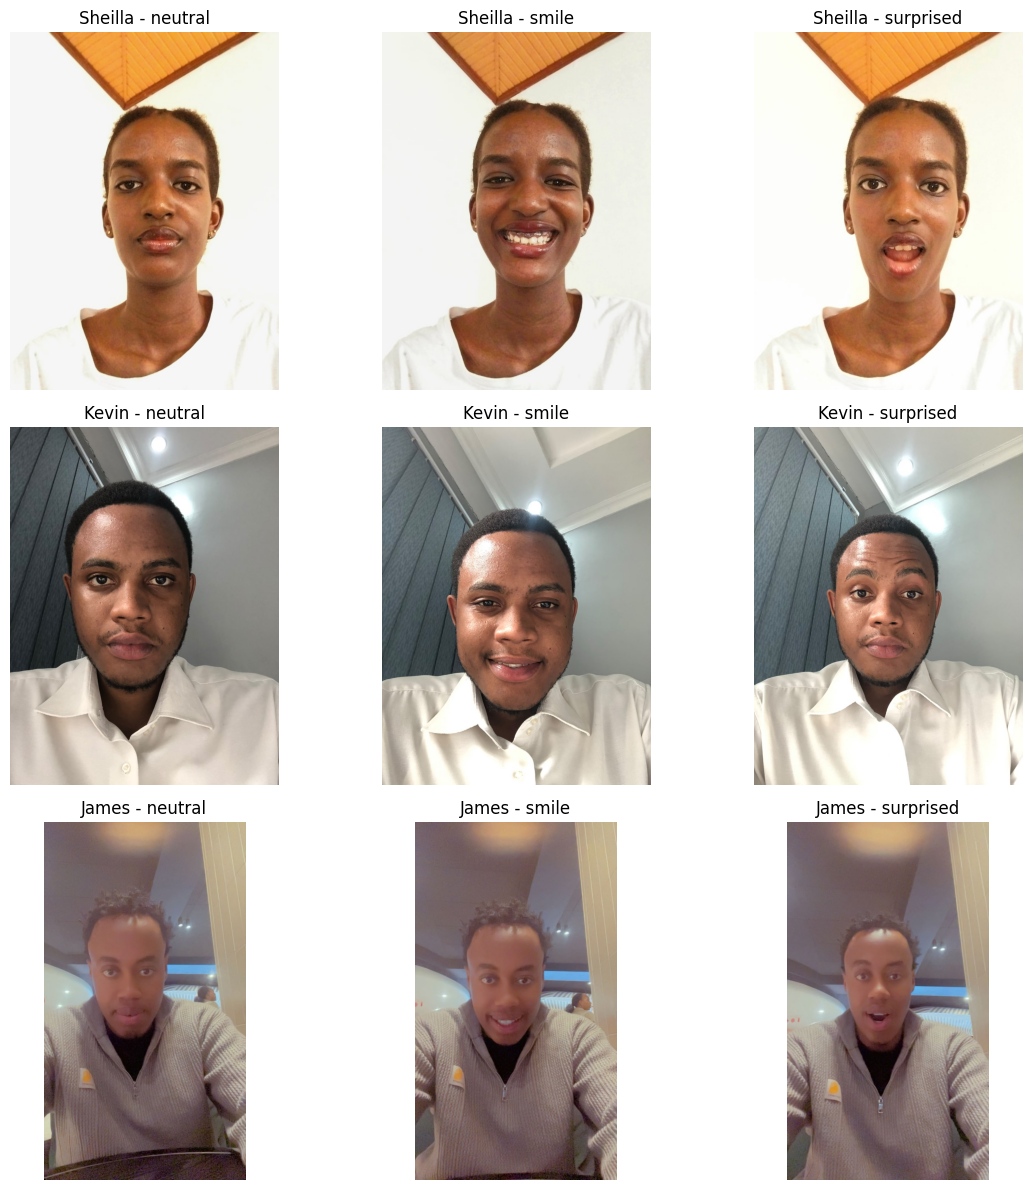

In [ ]:
def load_all_images(base_dir, members, expressions):
    variants = {
        "neutral": ["neutral"],
        "smile": ["smile", "smiling"],
        "surprised": ["surprised", "suprised", "surprise"],
    }

    data = []
    for member in members:
        member_dir = os.path.join(base_dir, member)
        if not os.path.isdir(member_dir):
            continue
        files_in_folder = os.listdir(member_dir)

        for expr in expressions:
            match = None
            for fname in files_in_folder:
                lower = fname.lower()
                if any(v in lower for v in variants.get(expr, [expr])):
                    match = fname
                    break
            if match:
                path = os.path.join(member_dir, match)
                img = cv2.imread(path)
                if img is not None:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    data.append({"member": member, "expression": expr, "image": img, "path": path})

    return data

image_data = load_all_images(BASE_DIR, MEMBERS, EXPRESSIONS)
print(f"Loaded {len(image_data)} images total")

n = len(image_data)
if n > 0:
    cols = 3
    rows = (n // cols) + (1 if n % cols else 0)
    plt.figure(figsize=(12, 4 * rows))
    for i, item in enumerate(image_data):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(item["image"])
        plt.title(f'{item["member"]} - {item["expression"]}')
        plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No images found yet — upload images in the cells above first.")

## 3. Apply augmentations

At least 2 augmentations per image: **rotation**, **flip**, **grayscale** (3 provided, easily
extendable). Applied to every image collected from every member.

Total images after augmentation: 36


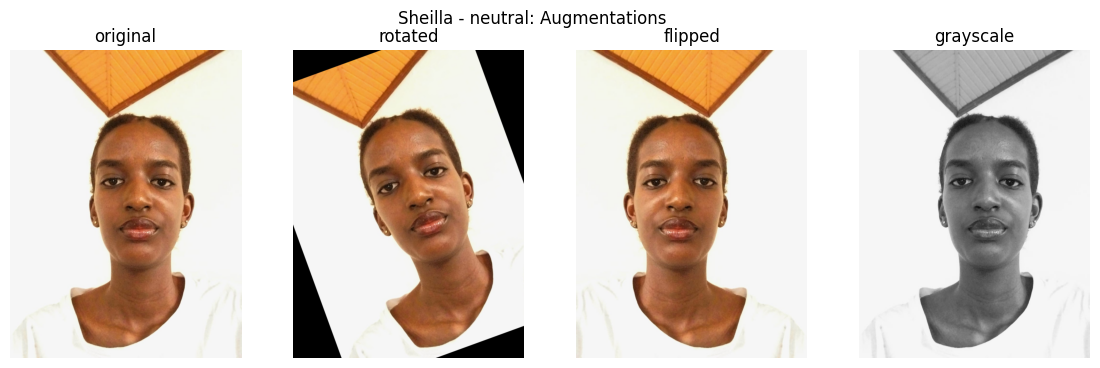

In [ ]:
def rotate_image(img, angle=20):
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h))

def flip_image(img):
    return cv2.flip(img, 1)

def grayscale_image(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    return cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)

def augment_image(img):
    return {
        "original": img,
        "rotated": rotate_image(img, angle=20),
        "flipped": flip_image(img),
        "grayscale": grayscale_image(img),
    }

augmented_dataset = []
for item in image_data:
    for aug_name, aug_img in augment_image(item["image"]).items():
        augmented_dataset.append({
            "member": item["member"],
            "expression": item["expression"],
            "augmentation": aug_name,
            "image": aug_img,
        })

print(f"Total images after augmentation: {len(augmented_dataset)}")

if image_data:
    sample = image_data[0]
    augs = augment_image(sample["image"])
    plt.figure(figsize=(14, 4))
    for i, (name, img) in enumerate(augs.items()):
        plt.subplot(1, 4, i + 1)
        plt.imshow(img)
        plt.title(name)
        plt.axis("off")
    plt.suptitle(f'{sample["member"]} - {sample["expression"]}: Augmentations')
    plt.show()

## 4. Feature extraction → `image_features.csv`

Features combine:
- **HOG** (Histogram of Oriented Gradients) — captures shape/edge structure of the face
- **Color histograms** (per RGB channel) — captures skin tone / lighting distribution

This gives a numeric feature vector per image that classical ML models (Random Forest,
Logistic Regression, etc.) can use for facial recognition.

In [ ]:
def extract_features(img, size=(128, 128)):
    resized = cv2.resize(img, size)
    gray = cv2.cvtColor(resized, cv2.COLOR_RGB2GRAY)

    hog_features = hog(
        gray, orientations=9, pixels_per_cell=(16, 16),
        cells_per_block=(2, 2), block_norm="L2-Hys"
    )

    hist_features = []
    for ch in range(3):
        hist = cv2.calcHist([resized], [ch], None, [32], [0, 256])
        hist_features.extend(hist.flatten())
    hist_features = np.array(hist_features)
    hist_features = hist_features / (np.sum(hist_features) + 1e-6)

    return np.concatenate([hog_features, hist_features])

rows = []
for item in augmented_dataset:
    feats = extract_features(item["image"])
    row = {
        "member": item["member"],
        "expression": item["expression"],
        "augmentation": item["augmentation"],
    }
    row.update({f"feat_{i}": v for i, v in enumerate(feats)})
    rows.append(row)

features_df = pd.DataFrame(rows)
features_df.to_csv("image_features.csv", index=False)
print(f"Saved image_features.csv with shape {features_df.shape}")
features_df.head()

Saved image_features.csv with shape (36, 1863)


,member,expression,augmentation,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,...,feat_1850,feat_1851,feat_1852,feat_1853,feat_1854,feat_1855,feat_1856,feat_1857,feat_1858,feat_1859
0,Sheilla,neutral,original,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000427,0.000285,0.000509,0.000977,0.001546,0.003743,0.009094,0.023682,0.169779,0.000671
1,Sheilla,neutral,rotated,0.003121,0.014894,0.311276,0.077556,0.311276,0.067429,0.001635,...,0.000407,0.000387,0.000651,0.000610,0.000956,0.002116,0.007060,0.018717,0.138692,0.000529
2,Sheilla,neutral,flipped,0.179184,0.000000,0.006516,0.002111,0.227451,0.201993,0.400101,...,0.000427,0.000285,0.000509,0.000977,0.001546,0.003743,0.009094,0.023682,0.169779,0.000671
3,Sheilla,neutral,grayscale,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.007019,0.000997,0.000610,0.000387,0.000387,0.000549,0.002482,0.005269,0.202026,0.000122
4,Sheilla,smile,original,0.016151,0.000000,0.003807,0.000000,0.008076,0.000000,0.008883,...,0.000488,0.000448,0.000732,0.001851,0.004456,0.017537,0.035990,0.060628,0.088501,0.000020


## 5. Build, train & evaluate the Facial Recognition Model

Random Forest classifier: given a feature vector, predict *which group member* the face
belongs to. Evaluated with Accuracy, weighted F1-score, and Log Loss — matching the rubric's
required metrics.

In [ ]:
feature_cols = [c for c in features_df.columns if c.startswith("feat_")]
X = features_df[feature_cols].values
y = features_df["member"].values

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.25, random_state=42, stratify=y_encoded
)

model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")
loss = log_loss(y_test, y_proba, labels=list(range(len(le.classes_))))

print("Facial Recognition Model — Evaluation")
print(f"Accuracy : {acc:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"Log Loss  : {loss:.4f}")

Facial Recognition Model — Evaluation
Accuracy : 1.0000
F1-Score  : 1.0000
Log Loss  : 0.1888


## 6. Simulate an "unauthorized" face attempt

This mirrors the **Facial Recognition Model** checkpoint in the system flow diagram from the
assignment: a face comes in, the model predicts identity + confidence, and access is
granted/denied based on a confidence threshold.

- First: an **authorized** attempt using a real group member's photo (should be granted)
- Then: an **unauthorized** attempt using a photo of someone *not* in the group (should be denied)

In [ ]:
def authenticate_face(img, model, label_encoder, confidence_threshold=0.6):
    features = extract_features(img).reshape(1, -1)
    proba = model.predict_proba(features)[0]
    best_idx = np.argmax(proba)
    confidence = proba[best_idx]
    predicted_member = label_encoder.inverse_transform([best_idx])[0]
    access_granted = confidence >= confidence_threshold
    return access_granted, predicted_member, confidence

test_item = image_data[0]
auth_granted, auth_member, auth_conf = authenticate_face(test_item["image"], model, le)
print("=== AUTHORIZED ATTEMPT ===")
print(f"Input: {test_item['member']} ({test_item['expression']})")
print(f"Predicted: {auth_member}, Confidence: {auth_conf:.2f}")
print("Access GRANTED" if auth_granted else "Access DENIED")

In [ ]:
print("Upload an 'unauthorized' face image (someone NOT in your group)")
unauth_upload = files.upload()
unauth_path = list(unauth_upload.keys())[0]

unauth_img = cv2.imread(unauth_path)
unauth_img = cv2.cvtColor(unauth_img, cv2.COLOR_BGR2RGB)

unauth_granted, unauth_member, unauth_conf = authenticate_face(unauth_img, model, le)
print("=== UNAUTHORIZED ATTEMPT ===")
print(f"Closest match: {unauth_member}, Confidence: {unauth_conf:.2f}")
print("Access GRANTED" if unauth_granted else "Access DENIED (unrecognized face)")

plt.imshow(unauth_img)
plt.title(f"Unauthorized Attempt -> {'GRANTED' if unauth_granted else 'DENIED'} (conf={unauth_conf:.2f})")
plt.axis("off")
plt.show()

## Summary

**Members processed:** Sheilla, Kevin, James

**Pipeline results**
- Raw images loaded: `[X]` / 9 expected (3 members × 3 expressions)
- Images after augmentation (rotate, flip, grayscale): `[X]`
- Feature rows saved to `image_features.csv`: `[X]` rows × `[X]` columns

**Facial Recognition Model (Random Forest)**
- Accuracy: `[0.XX]`
- F1-Score: `[0.XX]`
- Log Loss: `[0.XX]`

**Access simulation**
- Authorized attempt → predicted: `[name]`, confidence: `[0.XX]` → **GRANTED**
- Unauthorized attempt → closest match: `[name]`, confidence: `[0.XX]` → **DENIED**

**Deliverables produced**
- `image_features.csv` — merged into the group's multimodal dataset
- `authenticate_face()` — the group's Facial Recognition Model checkpoint

**Still needed:** merge with `audio_features.csv` + tabular data, and wire `authenticate_face()` into the shared CLI/mini-app demo.